## Import External Packages

In [1]:
import os, sys, glob
import numpy as np
import matplotlib.pyplot as plt

## Import Tender Analysis Packages

In [2]:
from src import (
    SifFile,
    find_sif_files,
    compute_background,
    extract_signal,
    CurvatureCorrection,
    OnePot,
    OnePotRIXS
)

## Set Data Directory

In [3]:
# Na2SO4 example data set
DATA = '/sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/Na2SO4/*.sif'
files = find_sif_files(DATA)

print(f'{len(files)} *.sif files found in {DATA[:-5]}:\n {files[0][56:]}, {files[1][56:]}... \n ... {files[-1][56:]}')

84 *.sif files found in /sdf/group/ssrl/dsokaras/bl6-2a/tender_data/twopot/data/Na2SO4/:
 Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2465.00.sif, Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_2467.00.sif... 
 ... Na2SO4/Na2SO4_pellet_20pcSucrose_SKa_RIXS_01_dark.sif


## 1. Reading a SIF file

`SifFile` wraps `sif_parser` for the image data and parses the acquisition
comment for additional parameters (e.g. `I0` / `I1` / `mono`).

In [4]:
sif = SifFile(files[30])

### A. Metadata
Various metadata is available from the file comment including:
- X-ray parameters: `I0`, `I1`, `mono`,
- CCD parameters: `exptime`, `numkins`
- Motor positions: `vert`,`Sx`, `Sy`

In [5]:
sif_dict = {
 "I0" : sif.I0,
 "I1" : sif.I1,
 "exposure time" : sif.exposure_time,
 "mono" : sif.mono,
 "num_frames" : sif.num_frames,
 "shape" : sif.shape,
 "metadata" : sif.metadata,
 "info" : sif.info
 }
sif_dict

{'I0': 8972.0,
 'I1': 57.0,
 'exposure time': 1.0,
 'mono': 2482.8,
 'num_frames': 1,
 'shape': (512, 2048),
 'metadata': {'mono': 2482.8,
  'I0': 8972.0,
  'I1': 57.0,
  'exptime': 1.0,
  'numkins': nan,
  'vert': 42.6981},
 'info': OrderedDict([('SifVersion', 65567),
              ('ExperimentTime', 1252658467),
              ('DetectorTemperature', -52.0),
              ('ExposureTime', 1.0),
              ('CycleTime', 2.577),
              ('AccumulatedCycleTime', 2.577),
              ('AccumulatedCycles', 1),
              ('StackCycleTime', 2.577),
              ('PixelReadoutTime', 1e-06),
              ('GainDAC', 0.0),
              ('GateWidth', 0.0),
              ('GratingBlaze', 1.6e-05),
              ('DetectorType', 'DV436'),
              ('DetectorDimensions', (2048, 2048)),
              ('OriginalFilename', b'Acquisition'),
              ('ShutterTime', (0.01, 0.0)),
              ('spectrograph', '999'),
              ('GateGain', 0.0),
              ('GateDelay'

### B. Raw Image and Spectrum
Frames can be accessed via indices using the `frame` method.   

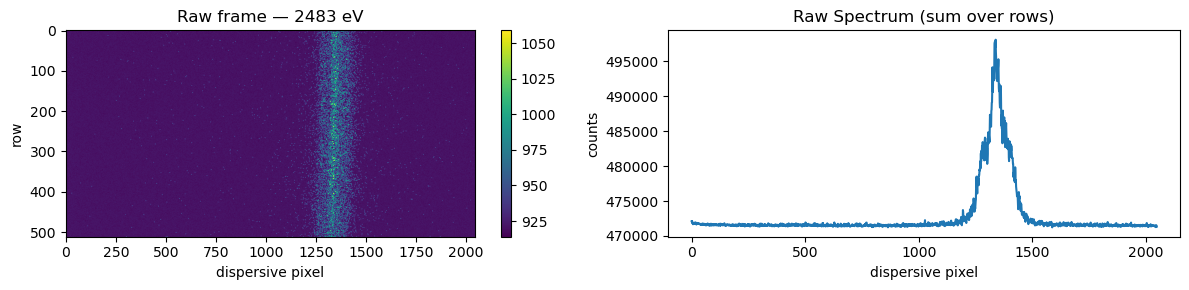

In [6]:
frame = sif.frame(0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3))
im = ax[0].imshow(frame, aspect='auto', vmin=np.percentile(frame, 1), vmax=np.percentile(frame, 99.5))
ax[0].set(title=f'Raw frame — {sif.mono:.0f} eV', xlabel='dispersive pixel', ylabel='row')
fig.colorbar(im, ax=ax[0])
ax[1].plot(frame.sum(axis=0))
ax[1].set(title='Raw Spectrum (sum over rows)', xlabel='dispersive pixel', ylabel='counts')
plt.tight_layout()

## 2. `OnePot` - XES Pipeline

`OnePot` ties the analysis stages together:   
Resolve files → background → extract → curvature-correct.   
**Note:** `bcg=None` computes the background from the data.

In this example we will analyze Mo VtC on the \[CpMo(CO)<sub>3</sub>\]<sub>2</sub> dimer complex.

In [4]:
!ls data/CPMoITriCO3Dimer/

CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_06_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_06.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_07_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_07.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_08_dark.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_08.sif
CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00e

### A. Loading .sif files

In [5]:
# Dimolybdenum sample example data set rXES at 2524.20 eV
#DATA2 = '/sdf/group/ssrl/dsokaras/bl6-2a/tender_data/2025-06_Tender/CPMoITriCO3Dimer/*MoL3val_2523.00eV_0*.sif'
DATA2 = './data/CPMoITriCO3Dimer/*MoL3val_2523.00eV_0*.sif'

files2 = find_sif_files(DATA2)

print(f'{len(files2)} *.sif files found in {DATA2[:-5]}:')
files2

18 *.sif files found in ./data/CPMoITriCO3Dimer/*MoL3val_2523.00eV_0:


['./data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_01_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_02_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_03_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_04_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_05_dark.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dimer_12mMol_Toluene_MoL3val_2523.00eV_06.sif',
 './data/CPMoITriCO3Dimer/CPMoITriCO3Dim

In [6]:
Mosif = SifFile(files2[0])
print('Data shape (num_frames, y-pixel, x-pixel):', Mosif.data.shape)
print('Number of frames:', Mosif.num_frames)

Data shape (num_frames, y-pixel, x-pixel): (80, 512, 2048)
Number of frames: 80


### B. `OnePot` Analysis

Analysis with parameters:
- `bcg = none` -> Compute background from the data.
- `histograms = True` -> Calculate the histogram for determining ADU filter thresholds.
- `thresholds = ...` -> Thresholds used for noise discrimination.
- `file_nbrs = [0]` -> Select which files to analyze (0-based indices; `[0]` = first file).

In [7]:
op = OnePot(files2, bcg=None, histograms=True, threshold=[100, 170, 350], file_nbrs=[0])
xes = op.run()
spec = xes.spectrum()

Text(0, 0.5, 'Counts')

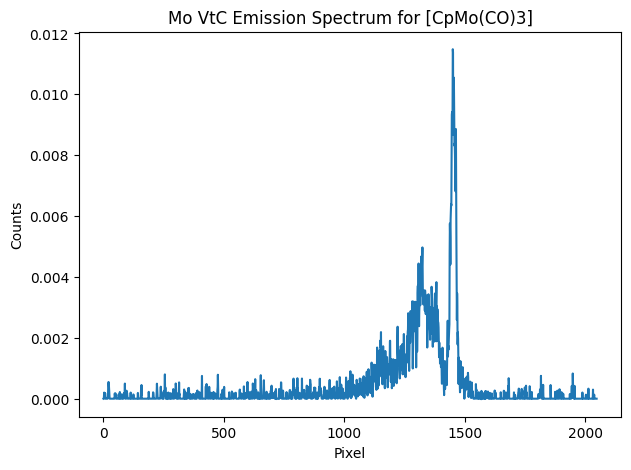

In [9]:
plt.figure(figsize=(7,5))

plt.plot(spec / np.trapezoid(spec))
plt.title("Mo VtC Emission Spectrum for [CpMo(CO)3]")
plt.xlabel("Pixel")
plt.ylabel("Counts")

Analysis with same parameters as above, selecting/slicing the first 20 frames.
- `scan_nbrs = range(20)` -> Select only frames 0-19 (0-based) for analysis from each file.

In [10]:
op2 = OnePot(files2, bcg=None, histograms=True, threshold=[100, 170, 350], file_nbrs=[0], scan_nbrs=range(20))
xes2 = op2.run()
spec2 = xes2.spectrum()

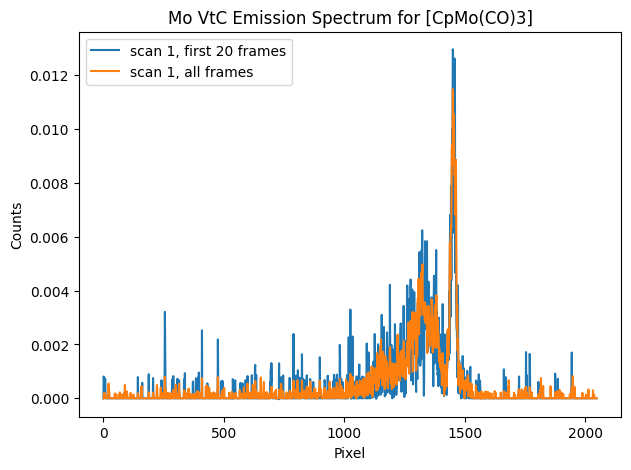

In [11]:
plt.figure(figsize=(7,5))

plt.plot(spec2 / np.trapezoid(spec2), label = 'scan 1, first 20 frames')
plt.plot(spec / np.trapezoid(spec), label = 'scan 1, all frames')
plt.title("Mo VtC Emission Spectrum for [CpMo(CO)3]")
plt.xlabel("Pixel")
plt.ylabel("Counts")
plt.legend()

### C. Diagnostic histograms - Determining ADU thresholds

In [34]:
H = xes.histograms
th = op.thresholds

print('Thresholds [bcg_cutoff, low, xray, hi] =', th.as_array())

Thresholds [bcg_cutoff, low, xray, hi] = [100. 170. 187. 350.]


X-ray event peak at ADU = 247


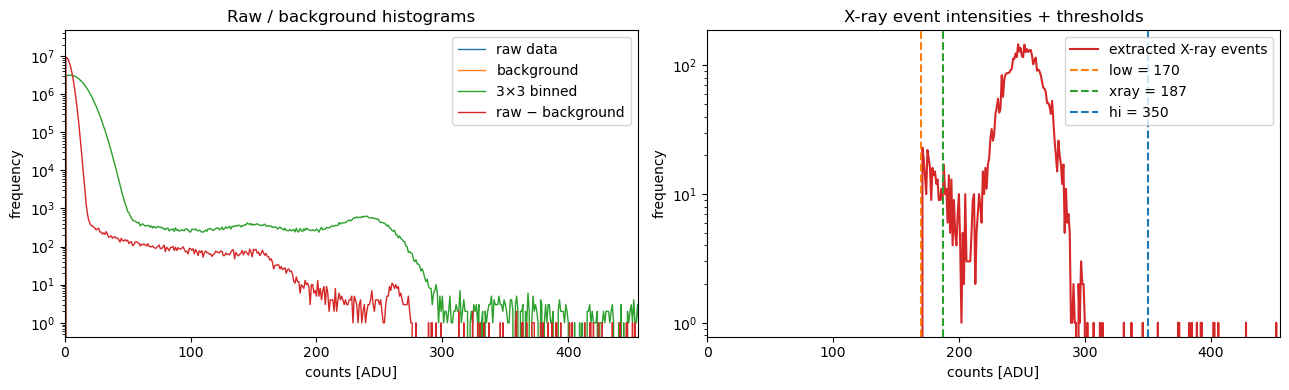

In [35]:
adu = np.arange(H['raw'].size)
fig, ax = plt.subplots(1, 2, figsize=(13,4))

# left: raw / background / binned — the "noise" side, log scale
for key, lbl in [('raw', 'raw data'), ('background', 'background'),
                 ('binned', '3×3 binned'), ('bkg_free', 'raw − background')]:
    ax[0].semilogy(adu, H[key], label=lbl, lw=1)
ax[0].set(title='Raw / background histograms', xlabel='counts [ADU]',
          ylabel='frequency', xlim=(0, 1.3 * th.hi))
ax[0].legend()

# right: extracted X-ray events with threshold markers
ax[1].semilogy(adu, H['xray'], color='C3', label='extracted X-ray events')
for val, name, c in [(th.low, 'low', 'C1'), (th.xray, 'xray', 'C2'), (th.hi, 'hi', 'C0')]:
    ax[1].axvline(val, ls='--', color=c, label=f'{name} = {val:.0f}')
ax[1].set(title='X-ray event intensities + thresholds', xlabel='counts [ADU]',
          ylabel='frequency', xlim=(0, 1.3 * th.hi))
ax[1].legend()
plt.tight_layout()

print('X-ray event peak at ADU =', int(np.argmax(H['xray'])))

### D. Curvature correction

The emission line is not perfectly straight across the dispersive axis: its
position along the 512 spatial rows drifts as a smooth (roughly quadratic)
function of dispersive pixel — the detector "banana." `CurvatureCorrection`
fits that drift by cross-correlation and shifts each dispersive column back into
vertical alignment.

**Note:** the correction shifts pixels *vertically* (along the rows that are
summed to make a spectrum). The row-summed 1-D emission spectrum
`signal.sum(axis=0)` is therefore almost unchanged by construction — summing a
column is invariant to shifting values within it. The effect shows up in the
**2-D image** and in any narrow emission-band cut (e.g. the RIXS/HERFD band),
*not* in the row-summed spectrum. Below we show the 2-D signal before/after and
the emission-line spatial profile (sum over the dispersive axis), which sharpens
as the banana is straightened.

In [ ]:
# Fit and apply the curvature correction to the extracted signal.
cc = CurvatureCorrection()
signal = xes.signal
corrected, _ = cc.fit_apply(signal)
print('fitted curvature coefficients t =', cc.t)

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))

vmax = np.percentile(signal, 99.8)
ax[0].imshow(signal, aspect='auto', vmax=vmax)
ax[0].set(title='Signal — before', xlabel='dispersive pixel', ylabel='row')
ax[1].imshow(corrected, aspect='auto', vmax=vmax)
ax[1].set(title='Signal — after curvature correction', xlabel='dispersive pixel')

# emission-line spatial profile (sum over dispersive axis) — sharpens after
ax[2].plot(signal.sum(axis=1), label='before')
ax[2].plot(corrected.sum(axis=1), label='after')
ax[2].set(title='Spatial profile (sum over dispersive axis)',
          xlabel='row', ylabel='counts')
ax[2].legend()
plt.tight_layout()

# The row-summed spectrum barely changes — quantify it:
sb, sa = signal.sum(axis=0), corrected.sum(axis=0)
print(f'row-summed spectrum max relative change: '
      f'{np.abs(sa - sb).max() / np.abs(sb).max():.2%}')

## 3. `OnePotRIXS` - RIXS + HERFD/XAS

The `OnePotRIXS` pipeline analyzes a complete set of emission spectra at fixed incident x-ray energies, assembling the emission pixel vs incident energy RIXS map. 

Use the `OnePotRIXS.herfd` method to select a RIXS cut at specified emission pixel (energy) and width.
Default is `central_pix = None`, where the central emission pixel is determined by gaussian fit to the summed emission spectrum. 

In this example, we will process the RIXS data for solid Na<sub>2</sub>SO<sub>4</sub> that was loaded above.

In [36]:
# Main analysis #
# Dark frame, i.e. _dark.sif is excluded by default, use 'exclude_dark=False' to process using the dark spectrum.
rixs = OnePotRIXS(files)

# Process RIXS map, HERFD cut (passing HERFD cut parameters) and TFY
out = rixs.herfd(central_pix=1280, n=7, i0_corr=True)

OnePotRIXS: excluded 1 dark frame(s) (*_dark.sif) from the scan


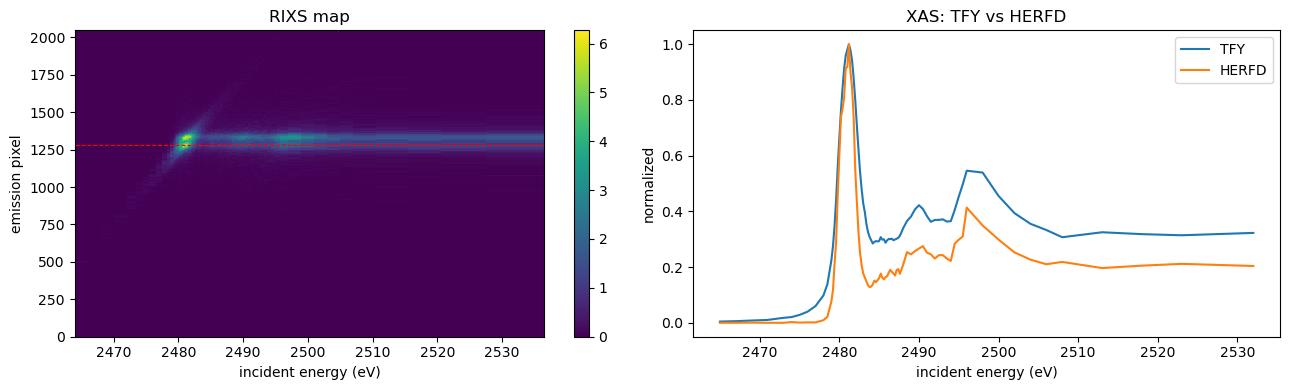

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

im = ax[0].pcolormesh(out.E, np.arange(out.rixs_map.shape[0]), out.rixs_map, shading='auto')
ax[0].set(title='RIXS map', xlabel='incident energy (eV)', ylabel='emission pixel')
ax[0].axhline(out.central_pix, color='r', lw=0.8, ls='--')
fig.colorbar(im, ax=ax[0])

ax[1].plot(out.E, out.TFY / np.nanmax(out.TFY), label='TFY')
ax[1].plot(out.E, out.HERFD / np.nanmax(out.HERFD), label='HERFD')
ax[1].set(title='XAS: TFY vs HERFD', xlabel='incident energy (eV)', ylabel='normalized'); ax[1].legend()

plt.tight_layout()

## 4. `index_beamtime` — batch a whole directory

A finalized beamtime folder holds many measurements mixed together. `index_beamtime`
parses the `.sif` filenames and groups them into runnable **`Measurement`** objects —
one `OnePot` per XES incident energy, one `OnePotRIXS` per RIXS series — with the
`_dark.sif` files auto-paired as the background. Operando-echem and calibration/alignment
files are skipped by default (and reported in `.skipped`, never silently dropped).

Each `Measurement` builds and runs the right pipeline via `.run()`, and results can be
written to annotated text either at an explicit path (`result.save_txt(path)`) or
auto-named into an output directory (`measurement.save_result(result, root=...)`).

In [ ]:
from src import index_beamtime

# Index the emission dataset: one XES measurement per incident energy.
idx = index_beamtime('./data/CPMoITriCO3Dimer')
print(f'{len(idx)} measurements found (skipped: {[(k, len(v)) for k, v in idx.skipped.items()]}):')
for m in idx:
    print('  ', m)

# Run one measurement and save it (auto-named into ./data/CPMoITriCO3Dimer/analysis/).
m = idx.by_kind('XES')[0]
result = m.run()                       # dark auto-paired as background
out_paths = m.save_result(result, root='./data/CPMoITriCO3Dimer')
print('\nwrote:', out_paths)

### Batch: run and save every measurement at once

`idx.run_all(**overrides)` runs every measurement, prints a progress line and
summary, and (with `save_root`) auto-saves each result. It returns a list of
`MeasurementRun` records (`.measurement`, `.result`, `.seconds`, `.error`,
`.saved_paths`); a measurement that fails is captured on its record rather than
aborting the batch. Overrides are keyword arguments passed through to each
pipeline — order does not matter.

`scan_nbrs=range(20)` below subsets frames per file to keep this demo quick;
drop it to process all frames.

In [ ]:
# Run + save all measurements in one call.
runs = idx.run_all(save_root='./data/CPMoITriCO3Dimer',
                   threshold=[100, 170, 350], scan_nbrs=range(20))

# Overlay the resulting emission spectra (one per incident energy).
plt.figure(figsize=(7, 5))
for run in runs:
    spec = run.result.spectrum()
    plt.plot(spec / np.trapezoid(spec),
             label=f'{run.measurement.incident_energy:g} eV', lw=1)
plt.title('Mo VtC emission — all incident energies (batch)')
plt.xlabel('Pixel'); plt.ylabel('Normalized counts')
plt.legend()